#  Predicción del precio de vuelos

### 1. Describe con detenimiento el problema de negocio que se desea resolver, y cómo se va a hacer esto. Indica la metodología, tareas a realizar, variable objetivo a predecir, etc.

### Problema de negocio
El problema de negocio consiste en predecir el precio de boletos de avión a partir de las características disponibles en los datos entregados. Esto es relevante para una agencia de viajes, aerolínea o plataforma de reservas, ya que permite entregar una estimación más precisa del valor que podría tener un vuelo según sus condiciones.

El precio de un vuelo puede depender de distintos factores, por ejemplo:

* aerolínea
* ciudad de origen
* ciudad de destino
* horario de salida
* horario de llegada
* duración del vuelo
* número de escalas
* días restantes antes del vuelo
* clase del boleto: economy o business 

La variable objetivo que se desea predecir es: PRICE

Como price es una variable numérica continua, este problema corresponde a un problema de regresión supervisada.

### Cómo se resolverá

Para resolver este problema se utilizará una metodología basada en el flujo típico de un proyecto de Data Science:

1. Cargar y unir los datasets de vuelos economy y business.
2. Agregar columna Class al dataset con economy y business
3. Revisar la calidad de los datos.
4. Realizar análisis exploratorio univariado y bivariado.
5. Analizar relaciones entre variables y precio.
6. Transformar las variables para que puedan ser usadas por modelos de Machine Learning.
7. Entrenar distintos modelos de regresión.
8. Optimizar hiperparámetros.
9. Evaluar los modelos usando métricas como MAE, RMSE y R².
10. Comparar los resultados contra un modelo baseline.
11. Seleccionar el mejor modelo y proponer próximos pasos.

### Metodología

Se aplicará una metodología iterativa similar a CRISP-DM, considerando las siguientes etapas:

| Etapa                      | Descripción                                                                 |
|---------------------------|-----------------------------------------------------------------------------|
| Comprensión del negocio   | Definir el objetivo: estimar precios de vuelos                              |
| Comprensión de los datos  | Revisar variables disponibles y estructura del dataset                      |
| Preparación de datos      | Limpieza, tratamiento de nulos, outliers y transformación de variables      |
| Modelamiento              | Entrenar modelos de regresión                                               |
| Evaluación                | Comparar modelos con métricas objetivas                                     |
| Conclusión                | Determinar utilidad del modelo y próximos pasos                             |

### 2. Carga los dataset entregados y genera un reporte de calidad de los mismos. Indica qué estrategias se van a utilizar para aquellos puntos encontrados (Indicar nulos, outliers, valores perdidos, que se hará con esto, etc.)

In [54]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, Ridge
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Cargamos los datasets
economic = pd.read_excel("economy.xlsx")
business = pd.read_excel("business.xlsx")

# Agregar clase
economic['class'] = 'economy'
business['class'] = 'business'

df = pd.concat([economic, business], ignore_index=True)

In [55]:
# Análisis general del dataset
def analisis_general(df):                                       # Función para realizar un análisis general del dataset
    print("ANÁLISIS GENERAL DEL DATASET\n")                     # Título del análisis
    
    # vista inicial
    print("Primeros registros:")                                # Mostrar las primeras filas del dataset
    display(df.head())                                          # Mostrar las primeras filas del dataset 

    # Tabla resumen de calidad (CLAVE)
    resumen = pd.DataFrame({                                    # Crear un DataFrame para resumir la calidad de los datos
        "Tipo de dato": df.dtypes,                              # Tipo de dato de cada columna
        "Nulos": df.isnull().sum(),                             # Cantidad de valores nulos en cada columna
        "% Nulos": (df.isnull().mean() * 100).round(2),         # Porcentaje de valores nulos en cada columna
        "Valores únicos": df.nunique()                          # Cantidad de valores únicos en cada columna
    }).sort_values(by="% Nulos", ascending=False)               # Ordenar el resumen por porcentaje de valores nulos de mayor a menor
    
    print("\nResumen de calidad de datos:")                     # Mostrar el resumen de calidad de los datos
    display(resumen)                                            # Mostrar el resumen de calidad de los datos

    # Duplicados
    print("\nDuplicados:", df.duplicated().sum())               # Mostrar la cantidad de filas duplicadas en el dataset

    # Estadísticas descriptivas (solo numéricas, más limpio)
    print("\nEstadísticas descriptivas:")                       # Mostrar las estadísticas descriptivas de las columnas numéricas del dataset
    display(df.describe())                                      # Mostrar las estadísticas descriptivas de las columnas numéricas del dataset

In [56]:
# Ejecutamos el análisis general
analisis_general(df)    # Llamar a la función para realizar el análisis general del dataset

ANÁLISIS GENERAL DEL DATASET

Primeros registros:


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,02h 10m,non-stop,21:05:00,Mumbai,5953,economy
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,02h 20m,non-stop,08:40:00,Mumbai,5953,economy
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,02h 10m,non-stop,06:35:00,Mumbai,5956,economy
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,02h 15m,non-stop,12:35:00,Mumbai,5955,economy
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,02h 20m,non-stop,11:10:00,Mumbai,5955,economy



Resumen de calidad de datos:


,Tipo de dato,Nulos,% Nulos,Valores únicos
date,datetime64[ns],0,0.0,49
airline,object,0,0.0,8
ch_code,object,0,0.0,8
num_code,int64,0,0.0,1255
dep_time,object,0,0.0,251
from,object,0,0.0,6
time_taken,object,0,0.0,483
stop,object,0,0.0,40
arr_time,object,0,0.0,266
to,object,0,0.0,6



Duplicados: 2

Estadísticas descriptivas:


,date,num_code
count,300261,300261.000000
mean,2022-03-08 00:06:26.447790592,1417.771709
min,2022-02-11 00:00:00,101.000000
25%,2022-02-25 00:00:00,637.000000
50%,2022-03-08 00:00:00,818.000000
75%,2022-03-20 00:00:00,927.000000
max,2022-03-31 00:00:00,9991.000000
std,NaN,1974.514439


### Reporte de calidad

A partir del análisis exploratorio inicial del dataset, se observan los siguientes aspectos relevantes:

### 1. Valores nulos
No se identifican valores nulos en ninguna de las variables.

Decisión:
* No se aplicarán técnicas de imputación.

### 2. Tipos de datos

Se identifican distintos tipos de variables:

* Numéricas:
   * num_code
* Variable objetivo
   * price (detectada como tipo object, lo cual es incorrecto)
* Categóricas (object):
   * airline, ch_code, from, to, departure_time, arrival_time, stops, time_taken
* Fecha:
   * date

Se detecta que la variable objetivo price se encuentra en formato object, lo que indica la presencia de caracteres no numéricos (como símbolos o separadores).

Decisión:
* Limpiar y convertir price a tipo numérico (float)
* Eliminar posibles valores inválidos generados durante la conversión
* Convertir variables temporales a formatos adecuados:
   * date → datetime (ya está correcto)
   * dep_time y arr_time → variables numéricas o categóricas derivadas
* Codificar variables categóricas mediante (OneHotEncoding)

### 3. Valores únicos
Variables como num_code presentan alta cardinalidad → no aportan valor predictivo directo.
Variables como airline, from y to, tienen menor cardinalidad → útiles para el modelo.

Decisión:
* Evaluar eliminar num_code si no aporta valor
* Mantener variables categóricas relevantes

### 4. Duplicados
Se detectan 2 registros duplicados 

Decisión:
* Eliminar duplicados para evitar sesgos en el modelamiento

### 5. Variables de tiempo
time_taken está en formato texto lo que impide su uso directo en modelos.

Decisión:
* Transformar a una variable numérica en minutos

### 6. Outliers
No se observan aún, pero se analizarán en EDA

Decisión:
* Detectar y analizar outliers en el análisis exploratorio mediante boxplots y métricas estadísticas

### Conclusión del análisis de calidad

El dataset presenta buena calidad general, sin valores nulos y con baja cantidad de duplicados.

No obstante, se identifican transformaciones necesarias para el modelamiento:

* Eliminación de duplicados
* Conversión de variable objetivo price a tipo numérico
* Conversión de variables de tiempo
* Codificación de variables categóricas
* Evaluación de variables irrelevantes

Estas acciones permitirán preparar los datos de forma adecuada para el entrenamiento de modelos de Machine Learning.

### 3. Genera un análisis exploratorio de los dataset entregados, un análisis univariado y bivariado. Prioriza los gráficos más importantes y entrega una conclusión a partir de estos.

### Análisis Univariado

In [57]:
# --- PRICE ---
df['price'] = df['price'].astype(str)                       # Convertir la columna price a string para poder aplicar limpieza de texto
df['price'] = df['price'].str.replace(",", "")              # Eliminar comas que actúan como separadores de miles
df['price'] = df['price'].str.replace("₹", "")              # Eliminar el símbolo de moneda (rupia)
df['price'] = df['price'].str.strip()                       # Eliminar espacios en blanco al inicio y al final
df['price'] = pd.to_numeric(df['price'], errors='coerce')   # Convertir la columna a numérica; valores inválidos se transforman en NaN

# --- TIME_TAKEN ---
def convertir_duracion(x):      # Función para convertir la duración a minutos
    if pd.isna(x):              # Verificar si el valor es nulo             
        return None             # Si el valor es nulo, retornar None
    
    h = re.search(r'(\d+)h', x) # Buscar la cantidad de horas en el texto
    m = re.search(r'(\d+)m', x) # Buscar la cantidad de minutos en el texto
    
    horas = int(h.group(1)) if h else 0     # Extraer número de horas; si no existe, asignar 0
    minutos = int(m.group(1)) if m else 0   # Extraer número de minutos; si no existe, asignar 0
    
    return horas * 60 + minutos             # Convertir todo a minutos (horas*60 + minutos)

df['duration_min'] = df['time_taken'].apply(convertir_duracion)         # Aplicar la función a la columna time_taken para crear duration_min
df['stops_num'] = df['stop'].str.extract('(\d+)').fillna(0).astype(int) # Extraer el número de escalas desde texto, reemplazar NaN por 0 y convertir a entero
df = df.drop_duplicates()                                               # Eliminar filas duplicadas del dataset

In [58]:
sns.set(style="whitegrid") # Establece un estilo visual para los gráficos, mejorando la legibilidad mediante una grilla de fondo

1. Distribución del precio

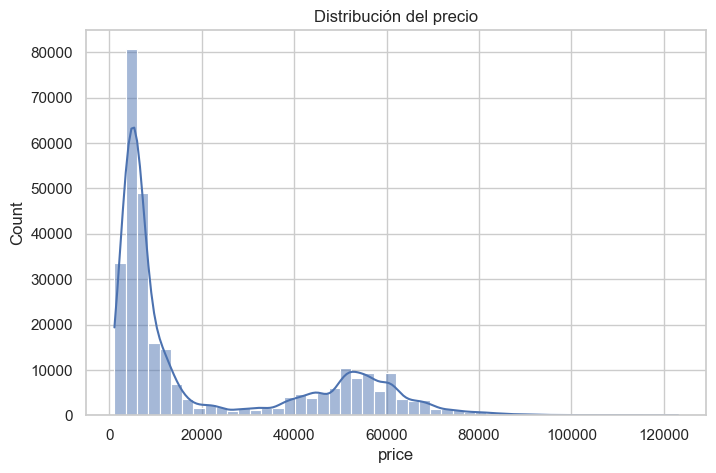

In [59]:
plt.figure(figsize=(8,5))                    # Crear una nueva figura para el gráfico con tamaño de 8x5 pulgadas
sns.histplot(df['price'], bins=50, kde=True) # Crear un histograma de la columna 'price' con 50 bins y una curva KDE para mostrar la distribución
plt.title("Distribución del precio")         # Establecer el título del gráfico
plt.show()                                   # Mostrar el gráfico en pantalla

El precio presenta una distribución sesgada a la derecha, con predominancia de valores bajos y presencia de outliers en precios altos.

2. Distribución de duración del vuelo

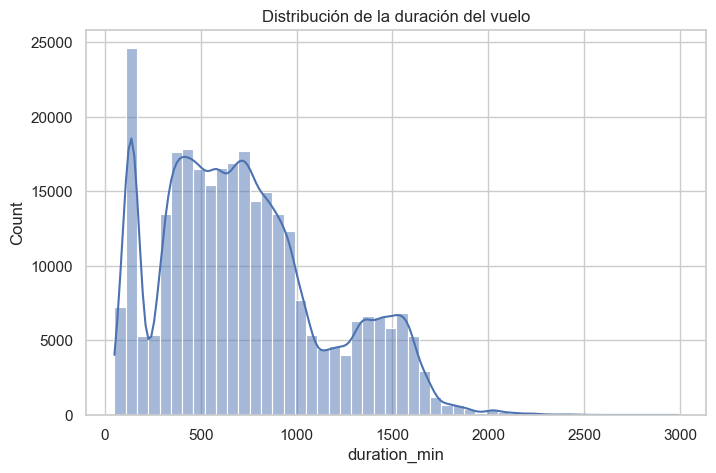

In [60]:
plt.figure(figsize=(8,5))                           # Crear una nueva figura para el gráfico con tamaño de 8x5 pulgadas
sns.histplot(df['duration_min'], bins=50, kde=True) # Crear un histograma de la columna 'duration_min' con 50 bins y una curva KDE para mostrar la distribución
plt.title("Distribución de la duración del vuelo")  # Establecer el título del gráfico
plt.show()                                          # Mostrar el gráfico en pantalla

La duración del vuelo presenta una distribución sesgada a la derecha, con predominio de vuelos cortos y presencia de vuelos largos menos frecuentes.

3. Frecuencia de vuelos por aerolínea

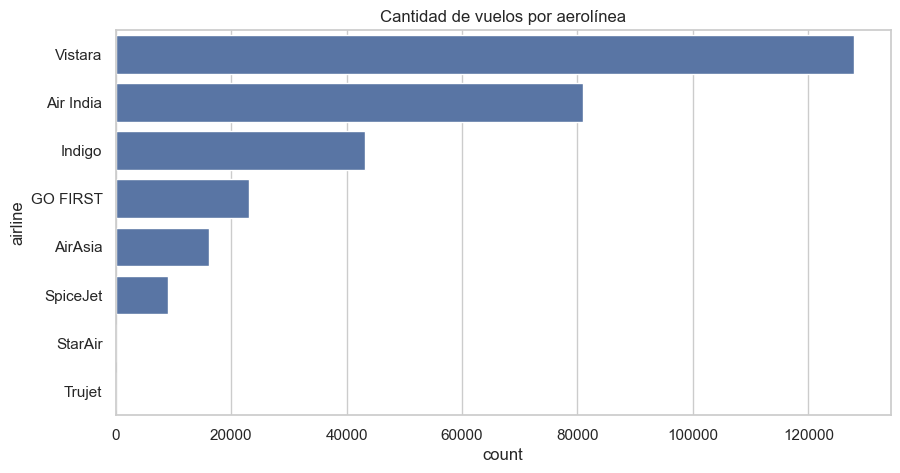

In [61]:
plt.figure(figsize=(10,5))                                                      # Crear una nueva figura para el gráfico con tamaño de 10x5 pulgadas
sns.countplot(y='airline', data=df, order=df['airline'].value_counts().index)   # Crear un gráfico de barras horizontales para contar la cantidad de vuelos por aerolínea, ordenando las aerolíneas por frecuencia
plt.title("Cantidad de vuelos por aerolínea")                                   # Establecer el título del gráfico
plt.show()                                                                      # Mostrar el gráfico en pantalla

Algunas aerolíneas concentran la mayoría de los vuelos, evidenciando un desbalance en la representación del dataset.

4. Numero de escalas por vuelos

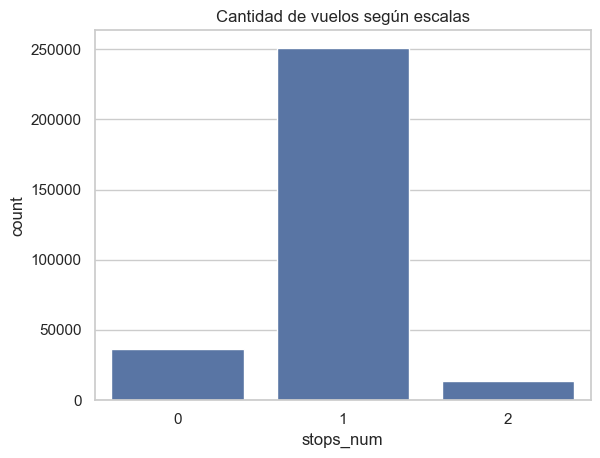

In [62]:
sns.countplot(x='stops_num', data=df)           # Crear un gráfico de barras para contar la cantidad de vuelos según el número de escalas
plt.title("Cantidad de vuelos según escalas")   # Establecer el título del gráfico
plt.show()                                      # Mostrar el gráfico en pantalla

La mayoría de los vuelos presenta una escala, evidenciando un desbalance en la distribución de esta variable.

### Análisis Bivariado

1. Precio vs Aerolínea

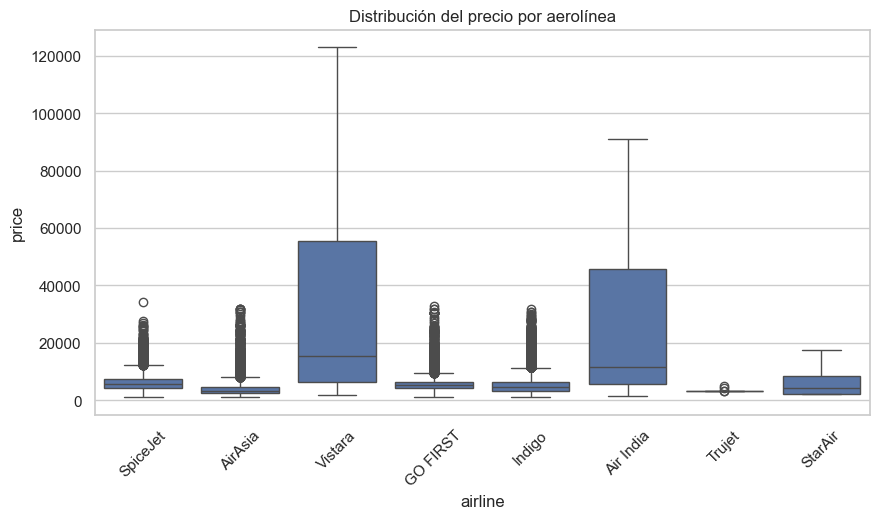

In [63]:
plt.figure(figsize=(10,5))                          # Crear una nueva figura para el gráfico con tamaño de 10x5 pulgadas
sns.boxplot(x='airline', y='price', data=df)        # Crear un gráfico de caja para mostrar la distribución del precio por aerolínea
plt.title("Distribución del precio por aerolínea")  # Establecer el título del gráfico    
plt.xticks(rotation=45)                             # Rotar las etiquetas del eje x 45 grados para mejorar la legibilidad
plt.show()                                          # Mostrar el gráfico en pantalla

Se observan diferencias significativas en la distribución de precios entre las distintas aerolíneas.

Aerolíneas como Vistara y Air India presentan mayores precios y una alta variabilidad, mientras que otras como AirAsia, Indigo y SpiceJet muestran precios más bajos y menor dispersión.

Esto indica que la aerolínea es una variable relevante en la determinación del precio del vuelo.

2. Precio vs duración

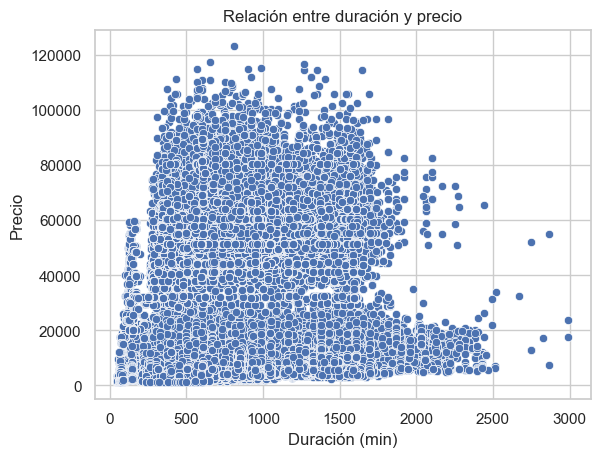

In [64]:
sns.scatterplot(x='duration_min', y='price', data=df)   # Crear un gráfico de dispersión para mostrar la relación entre duración del vuelo y precio
plt.title("Relación entre duración y precio")           # Establecer el título del gráfico
plt.xlabel("Duración (min)")                            # Establecer la etiqueta del eje x
plt.ylabel("Precio")                                    # Establecer la etiqueta del eje y
plt.show()                                              # Mostrar el gráfico en pantalla

Se observa una relación positiva entre la duración del vuelo y el precio, donde vuelos más largos tienden a ser más costosos, aunque con alta dispersión de valores.

3. Precio vs Escalas 

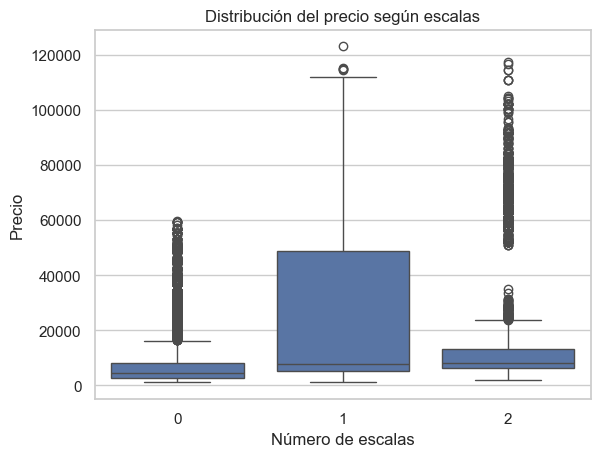

In [65]:
sns.boxplot(x='stops_num', y='price', data=df)      # Crear un gráfico de caja para mostrar la distribución del precio según el número de escalas
plt.title("Distribución del precio según escalas")  # Establecer el título del gráfico
plt.xlabel("Número de escalas")                     # Establecer la etiqueta del eje x
plt.ylabel("Precio")                                # Establecer la etiqueta del eje y
plt.show()                                          # Mostrar el gráfico en pantalla

Se observa que los vuelos con una escala presentan mayor variabilidad y precios más altos en comparación con vuelos directos, mientras que aquellos con dos escalas tienden a tener precios intermedios.

4. Precio vs clase

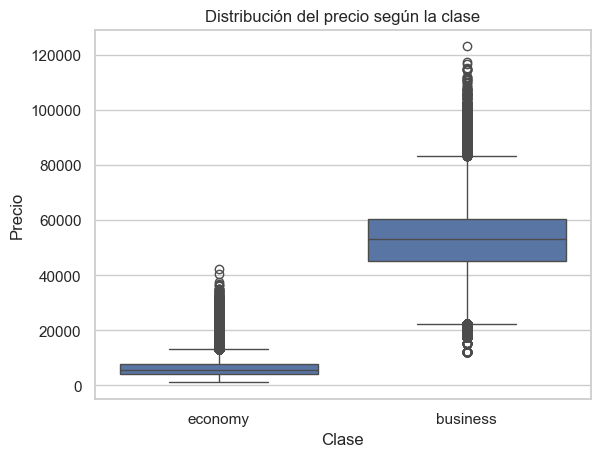

In [66]:
sns.boxplot(x='class', y='price', data=df)          # Crear un gráfico de caja para mostrar la distribución del precio según la clase (economy o business)
plt.title("Distribución del precio según la clase") # Establecer el título del gráfico
plt.xlabel("Clase")                                 # Establecer la etiqueta del eje x
plt.ylabel("Precio")                                # Establecer la etiqueta del eje y
plt.show()                                          # Mostrar el gráfico en pantalla

Se observa una diferencia significativa en el precio según la clase del vuelo, siendo la clase business considerablemente más costosa que economy.

### Conclusión general del análisis exploratorio

El análisis exploratorio permitió identificar patrones relevantes en los datos:

- El precio presenta una distribución sesgada con presencia de valores extremos.
- La duración del vuelo muestra una relación positiva con el precio.
- La aerolínea influye significativamente en el valor del ticket.
- El número de escalas impacta el precio, observándose mayor variabilidad en vuelos con una escala.
- La clase del vuelo es una de las variables más determinantes en el precio.

En conjunto, estas variables serán fundamentales para el modelamiento, ya que muestran una relación directa con la variable objetivo.

### 4. Realiza un análisis de correlaciones entre las diferentes variables existentes, identificando cuáles son las variables más importantes para la predicción de la variable objetivo. Utiliza las técnicas vistas en el curso.

In [67]:
df_corr = df[['price','duration_min','stops_num','class','airline']].copy() # Crear un nuevo DataFrame con las columnas relevantes para el análisis de correlación
df_corr = pd.get_dummies(df_corr, drop_first=True)                          # Convertir las variables categóricas en variables dummy (one-hot encoding), eliminando la primera categoría para evitar multicolinealidad
corr_full = df_corr.corr()                                                  # Calcular la matriz de correlación para el DataFrame preparado para análisis de correlación

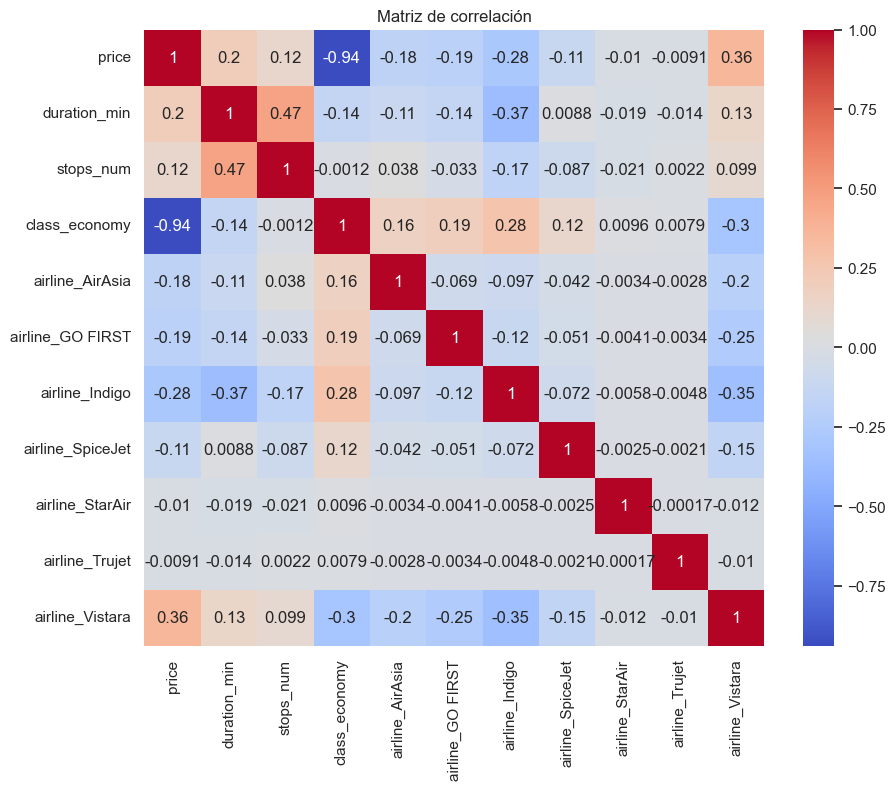

In [68]:
plt.figure(figsize=(10,8))                          # Crear una nueva figura para el gráfico con tamaño de 10x8 pulgadas
sns.heatmap(corr_full, annot=True, cmap='coolwarm') # Crear un mapa de calor para visualizar la matriz de correlación, con anotaciones de los valores y una paleta de colores 'coolwarm' para resaltar las correlaciones positivas y negativas
plt.title("Matriz de correlación")                  # Establecer el título del gráfico
plt.show()                                          # Mostrar el gráfico en pantalla

In [69]:
# Selección de variables por correlación
corr_target = df_corr.corr()["price"]                                   # Obtener la correlación con el target como Serie       
corr_target = corr_target.drop("price")                                 # Eliminar el propio target
selected_features_corr = corr_target[abs(corr_target) >= 0.20].index    # Seleccionar variables cuya correlación absoluta sea mayor o igual a 0.20 positivas o negativas
selected_features_corr                                                  # Mostrar las variables seleccionadas por correlación con el target (precio)

Index(['duration_min', 'class_economy', 'airline_Indigo', 'airline_Vistara'], dtype='object')

In [70]:
# correlación con el target
corr_target = df_corr.corr()["price"].drop("price")     # Calcular la correlación de todas las variables con el target y elimina el target                                           
corr_filtrado = corr_target.loc[selected_features_corr] # tomar solo las variables seleccionadas
print(corr_filtrado)                                    # Mostrar resultados

duration_min       0.204477
class_economy     -0.937868
airline_Indigo    -0.280741
airline_Vistara    0.360956
Name: price, dtype: float64


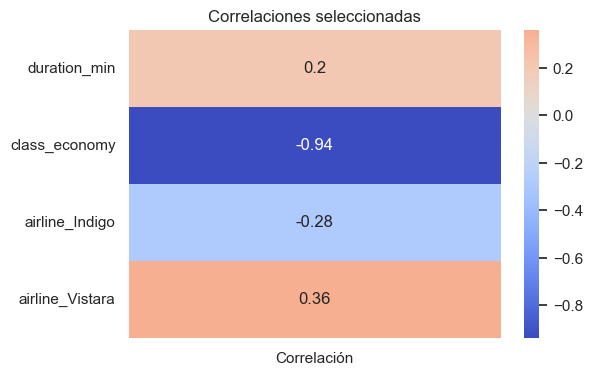

In [71]:
# convertir a DataFrame
corr_df = corr_filtrado.to_frame(name="Correlación") # Convertir la Serie de correlaciones a DataFrame

plt.figure(figsize=(6, 4))  # Crear figura
sns.heatmap(                # Crear heatmap
    corr_df,                # datos a visualizar
    annot=True,             # mostrar valores numéricos en cada celda
    cmap="coolwarm",        # rojo = positivo, azul = negativo
    center=0                # centrar la escala en 0 (clave para interpretar signos)
)

plt.title("Correlaciones seleccionadas") # Título del gráfico
plt.show()                               # Mostrar Gráfico       

El análisis de correlaciones permitió identificar las variables más influyentes en la predicción del precio.

La variable con mayor impacto es la clase del vuelo, evidenciada por una fuerte correlación negativa de class_economy, lo que indica que los vuelos en clase business presentan precios considerablemente más altos.

Asimismo, la duración del vuelo muestra una correlación positiva con el precio, indicando que vuelos más largos tienden a ser más costosos.

Por otro lado, algunas aerolíneas presentan comportamientos diferenciados, destacando Vistara con una correlación positiva (mayores precios) e Indigo con una correlación negativa (precios más bajos).

En conjunto, se identifican como variables más relevantes para el modelamiento: la clase del vuelo, la duración y la aerolínea.

Se debe considerar que la correlación de Pearson mide relaciones lineales, por lo que podrían existir relaciones no lineales no capturadas en este análisis.

Analisis adicional de variables

In [72]:
# Análisis de correlación ampliado incluyendo variables de origen y destino
df_corr_extra = df[['price','duration_min','stops_num','airline','class','from','to']].copy()   # Crear un subconjunto del DataFrame incluyendo más variables (origen y destino) para ampliar el análisis de correlación
df_corr_extra = pd.get_dummies(df_corr_extra, drop_first=True)                                  # Convertir variables categóricas ('airline', 'class', 'from', 'to') en variables numéricas usando OneHotEncoding
corr_extra = df_corr_extra.corr()['price'].drop('price').sort_values(ascending=False)           # Calcular la correlación de todas las variables con 'price'
corr_extra.head(10)                                                                             # Mostrar las 10 variables con mayor correlación con el precio

airline_Vistara    0.360956
duration_min       0.204477
stops_num          0.119799
to_Kolkata         0.021061
from_Chennai       0.018839
to_Chennai         0.018572
from_Kolkata       0.016235
from_Mumbai        0.013289
to_Mumbai          0.010594
to_Hyderabad      -0.008507
Name: price, dtype: float64

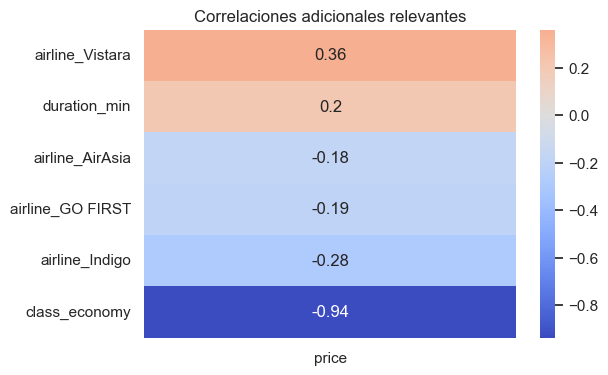

In [73]:
# Filtrar variables con correlación relevante (por ejemplo, > 0.15 o < -0.15)
top_vars = corr_extra[abs(corr_extra) > 0.15]                           # Filtrar variables cuya correlación absoluta sea mayor a 0.15 (positiva o negativa)
plt.figure(figsize=(6,4))                                               # Crear una nueva figura para el gráfico con tamaño de 6x4 pulgadas
sns.heatmap(top_vars.to_frame(), annot=True, cmap='coolwarm', center=0) # Crear un mapa de calor para visualizar las correlaciones relevantes, con anotaciones de los valores y una paleta de colores 'coolwarm' para resaltar las correlaciones positivas y negativas, centrando la escala en 0
plt.title("Correlaciones adicionales relevantes")                       # Establecer el título del gráfico
plt.show()                                                              # Mostrar el gráfico en pantalla

Se realizó un análisis adicional incorporando variables como ciudad de origen y destino.

Los resultados muestran que estas variables presentan una baja correlación con el precio, lo que indica que su impacto en la predicción es limitado en comparación con variables como la clase del vuelo, la aerolínea y la duración.

Esto confirma que las variables previamente seleccionadas son las más relevantes para el modelamiento.

### 5. Realiza las transformaciones necesarias para realizar el modelamiento posterior y crea las variables que estimes convenientes con ayuda del análisis previo y la expertise del negocio.

In [74]:
# Copia del dataset
df_model = df.copy()

# Limpieza de price
df_model['price'] = (
    df_model['price']
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.strip()
)

# Convertir a numérico, forzando errores a NaN para detectar problemas de conversión
df_model['price'] = pd.to_numeric(df_model['price'], errors='coerce')

# Transformar duración a minutos
def convertir_duracion(x):
    if pd.isna(x):
        return np.nan
    
    h = re.search(r'(\d+)h', x)
    m = re.search(r'(\d+)m', x)
    
    horas = int(h.group(1)) if h else 0
    minutos = int(m.group(1)) if m else 0
    
    return horas * 60 + minutos

# Aplicar la función a la columna time_taken para crear duration_min
df_model['duration_min'] = df_model['time_taken'].apply(convertir_duracion)

# Transformar escalas a número
df_model['stops_num'] = df_model['stop'].str.extract(r'(\d+)').fillna(0).astype(int)

# Eliminar nulos y duplicados
df_model = df_model.dropna(subset=['price', 'duration_min'])
df_model = df_model.drop_duplicates()

# Selección de variables relevantes
features = ['duration_min', 'stops_num', 'class', 'airline']
df_model = df_model[features + ['price']]

# Codificación de variables categóricas
df_model = pd.get_dummies(df_model, drop_first=True)

# Vista previa del dataset preparado para modelado
df_model.head()

,duration_min,stops_num,price,class_economy,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,airline_Trujet,airline_Vistara
0,130,0,5953,True,False,False,False,True,False,False,False
1,140,0,5953,True,False,False,False,True,False,False,False
2,130,0,5956,True,True,False,False,False,False,False,False
3,135,0,5955,True,False,False,False,False,False,False,True
4,140,0,5955,True,False,False,False,False,False,False,True


### Transformaciones realizadas

Para preparar los datos para el modelamiento posterior, se realizaron las siguientes transformaciones:

- Se convirtió la variable objetivo price a formato numérico.
- Se creó la variable duration_min, transformando time_taken desde texto a minutos.
- Se creó la variable stops_num, representando la cantidad de escalas del vuelo.
- Se eliminaron registros duplicados y valores inválidos.
- No se eliminaron outliers, ya que los valores extremos observados corresponden a situaciones reales del negocio, como vuelos business o vuelos de larga duración.
- Se seleccionaron variables relevantes a partir del análisis exploratorio y de correlación.
- Se aplicó OneHotEncoding a variables categóricas como class y airline.

Estas transformaciones permiten obtener un dataset preparado para el entrenamiento de modelos de Machine Learning.

Las variables seleccionadas para el modelamiento se basan tanto en el análisis de correlación como en criterios de negocio.

Si bien el análisis de correlación permitió identificar variables con mayor relación directa con el precio, se decidió mantener variables adicionales como "stops_num" y "airline", ya que podrían aportar valor predictivo al modelo al capturar relaciones no lineales.

Esto permite construir un modelo más robusto, especialmente al utilizar algoritmos como Random Forest.

### 6. Genera una función que encapsule el tratamiento de datos necesario, para entregar un dataset limpio y procesado a partir del dataset original.

In [75]:
# función para cargar y preprocesar los datos
def cargar_y_preprocesar(economy_path, business_path):      # Función para cargar los archivos de datos y realizar el preprocesamiento necesario para preparar el dataset para modelado
    # Cargar archivos
    economy = pd.read_excel(economy_path)                   # Cargar el archivo de datos de vuelos en clase económica desde la ruta especificada
    business = pd.read_excel(business_path)                 # Cargar el archivo de datos de vuelos en clase business desde la ruta especificada

    # Crear variable de clase antes de unir
    economy['class'] = 'economy'
    business['class'] = 'business'

    # Unir datasets
    df = pd.concat([economy, business], ignore_index=True)

    # Limpiar price
    df['price'] = (                         # ------------------------------
        df['price']                         # -- Limpiar la columna price --
        .astype(str)                        # -- eliminando comas,        --
        .str.replace(",", "", regex=False)  # -- símbolos de moneda       --
        .str.replace("₹", "", regex=False)  # -- y espacios               --
        .str.strip()                        # ------------------------------
    )
    df['price'] = pd.to_numeric(df['price'], errors='coerce')   # Convertir la columna a numérica; valores inválidos se transforman en NaN

    # Convertir duración a minutos
    def convertir_duracion(x):          # Función para convertir la duración a minutos
        if pd.isna(x):                  # Verificar si el valor es nulo
            return np.nan               # Si el valor es nulo, retornar NaN

        h = re.search(r'(\d+)h', x)     # Buscar la cantidad de horas en el texto
        m = re.search(r'(\d+)m', x)     # Buscar la cantidad de minutos en el texto

        horas = int(h.group(1)) if h else 0     # Extraer número de horas; si no existe, asignar 0
        minutos = int(m.group(1)) if m else 0   # Extraer número de minutos; si no existe, asignar 0

        return horas * 60 + minutos             # Convertir todo a minutos (horas*60 + minutos)

    df['duration_min'] = df['time_taken'].apply(convertir_duracion) # Aplicar la función a la columna time_taken para crear duration_min

    # Convertir escalas a número
    df['stop'] = df['stop'].astype(str)
    df['stops_num'] = df['stop'].str.extract(r'(\d+)').fillna(0).astype(int)

    # Eliminar nulos y duplicados
    df = df.dropna(subset=['price', 'duration_min'])
    df = df.drop_duplicates()

    # Selección de variables relevantes
    features = ['duration_min', 'stops_num', 'class', 'airline']
    df_model = df[features + ['price']].copy()

    # OneHotEncoding
    df_model = pd.get_dummies(df_model, drop_first=True).astype(int)

    # Separar variables
    X = df_model.drop('price', axis=1)
    y = df_model['price']

    return X, y, df_model

In [76]:
# Ejecutar función de carga y preprocesamiento
X, y, df_model = cargar_y_preprocesar("economy.xlsx", "business.xlsx")
print(X.shape)
print(y.shape)
df_model.head()

(300259, 10)
(300259,)


,duration_min,stops_num,price,class_economy,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,airline_StarAir,airline_Trujet,airline_Vistara
0,130,0,5953,1,0,0,0,1,0,0,0
1,140,0,5953,1,0,0,0,1,0,0,0
2,130,0,5956,1,1,0,0,0,0,0,0
3,135,0,5955,1,0,0,0,0,0,0,1
4,140,0,5955,1,0,0,0,0,0,0,1


### Función de preprocesamiento

Se implementó una función que encapsula el flujo completo de tratamiento de datos, desde la lectura de los archivos originales hasta la generación de un dataset listo para el modelamiento.

Esta función incluye:

- Carga de los archivos economy y business.
- Creación de la variable class para identificar el tipo de servicio.
- Limpieza y conversión de la variable objetivo price a formato numérico.
- Transformación de la variable time_taken a una variable numérica en minutos (duration_min).
- Creación de la variable stops_num a partir del número de escalas.
- Eliminación de valores nulos y registros duplicados.
- Selección de variables relevantes según el análisis exploratorio y de correlación.
- Codificación de variables categóricas mediante OneHotEncoding.

La función retorna las variables independientes (X) y la variable objetivo (y), listas para ser utilizadas en modelos de Machine Learning.

Además, esta implementación permite asegurar la reproducibilidad y consistencia del pipeline de datos.

### 7. Elige al menos 3 modelos candidatos para resolver el problema. A partir de esto, genera un conjunto de entrenamiento y prueba, para luego entrenar los diferentes modelos.

1. División entrenamiento / prueba

In [77]:
# Dividir en train y test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42    
)
print(X_train.shape, X_test.shape)  # Mostrar las dimensiones de los conjuntos de entrenamiento y prueba

(240207, 10) (60052, 10)


Regresion lineal

In [78]:
# Modelo 1: Regresión Lineal
lr = LinearRegression()     # Crear una instancia del modelo de Regresión Lineal
lr.fit(X_train, y_train)    # Entrenar el modelo de Regresión Lineal con los datos de entrenamiento

LinearRegression()

Arbol de Regresión

In [79]:
# Modelo 2: Árbol de decisión
dt = DecisionTreeRegressor(random_state=42) # Crear una instancia del modelo de Árbol de Decisión con una semilla para reproducibilidad
dt.fit(X_train, y_train)                    # Entrenar el modelo de Árbol de Decisión con los datos de entrenamiento

DecisionTreeRegressor(random_state=42)

Random Forest

In [80]:
# Modelo 3: Random Forest
rf = RandomForestRegressor(random_state=42, n_estimators=100)   # Crear una instancia del modelo de Random Forest con una semilla para reproducibilidad y 100 árboles
rf.fit(X_train, y_train)                                        # Entrenar el modelo de Random Forest con los datos de entrenamiento

RandomForestRegressor(random_state=42)

In [81]:
y_pred_lr = lr.predict(X_test)  # Realizar predicciones con el modelo de Regresión Lineal utilizando los datos de prueba
y_pred_dt = dt.predict(X_test)  # Realizar predicciones con el modelo de Árbol de Decisión utilizando los datos de prueba
y_pred_rf = rf.predict(X_test)  # Realizar predicciones con el modelo de Random Forest utilizando los datos de prueba

### Modelos candidatos

Para abordar el problema de predicción del precio de vuelos, se seleccionaron tres modelos de regresión:

- Regresión Lineal: utilizado como modelo base para establecer un punto de comparación.
- Árbol de Decisión: permite capturar relaciones no lineales entre variables.
- Random Forest: modelo basado en ensambles que mejora la capacidad predictiva y reduce el sobreajuste.

Se dividió el dataset en conjunto de entrenamiento (80%) y prueba (20%), permitiendo evaluar el desempeño de los modelos en datos no vistos.

Posteriormente, se entrenaron los tres modelos utilizando el conjunto de entrenamiento.

### 8. Elige una grilla de hiperparametros y luego optimízalos, buscando la mejor combinación para cada grilla. Guardar los modelos entrenados.

### Grilla Ridge

In [82]:
# Modelo 4: Ridge Regression con GridSearchCV
param_ridge = {
    'alpha': [0.01, 0.1, 1, 10]         # Lista de valores de alpha para probar en la búsqueda de hiperparámetros del modelo Ridge Regression
}
# Grilla Ridge
grid_ridge = GridSearchCV(              # Crear una instancia de GridSearchCV para realizar la búsqueda de hiperparámetros del modelo Ridge Regression
    Ridge(random_state=42),             # Crear una instancia del modelo Ridge Regression con una semilla para reproducibilidad
    param_ridge,                        # Especificar los hiperparámetros a probar en la búsqueda
    cv=5,                               # Número de folds para validación cruzada
    scoring='neg_mean_squared_error',   # Utilizar el error cuadrático medio negativo como métrica de evaluación para la búsqueda de hiperparámetros
    n_jobs=-1                           # Utilizar todos los núcleos disponibles para acelerar la búsqueda de hiperparámetros
)

grid_ridge.fit(X_train, y_train)        # Entrenar el modelo de Ridge Regression con búsqueda de hiperparámetros utilizando los datos de entrenamiento
best_ridge = grid_ridge.best_estimator_ # Obtener el mejor modelo de Ridge Regression encontrado por GridSearchCV
print("Mejor alpha Ridge:")             # Mostrar Mejor alpha Ridge:
print(grid_ridge.best_params_)          # Mostrar los mejores hiperparámetros encontrados por GridSearchCV para el modelo Ridge Regression

Mejor alpha Ridge:
{'alpha': 0.1}


In [83]:
y_pred_ridge = best_ridge.predict(X_test)   # Realizar predicciones con el mejor modelo de Ridge Regression encontrado por GridSearchCV utilizando los datos de prueba

### Grilla Lasso

In [84]:
# Modelo 5: Lasso Regression con GridSearchCV
param_lasso = {
    'alpha': [0.01, 0.1, 1, 10]         # Lista de valores de alpha para probar en la búsqueda de hiperparámetros del modelo Lasso Regression
}
# Grilla Lasso
grid_lasso = GridSearchCV(              # Crear una instancia de GridSearchCV para realizar la búsqueda de hiperparámetros del modelo Lasso Regression
    Lasso(max_iter=20000),              # Crear una instancia del modelo Lasso Regression con un número máximo de iteraciones para asegurar la convergencia
    param_lasso,                        # Especificar los hiperparámetros a probar en la búsqueda
    cv=5,                               # Número de folds para validación cruzada
    scoring='neg_mean_squared_error',   # Utilizar el error cuadrático medio negativo como métrica de evaluación para la búsqueda de hiperparámetros
    n_jobs=-1                           # Utilizar todos los núcleos disponibles para acelerar la búsqueda de hiperparámetros
)

grid_lasso.fit(X_train, y_train)        # Entrenar el modelo de Lasso Regression con búsqueda de hiperparámetros utilizando los datos de entrenamiento
best_lasso = grid_lasso.best_estimator_ # Obtener el mejor modelo de Lasso Regression encontrado por GridSearchCV
print("Mejor alpha Lasso:")             # Mostrar Mejor alpha Lasso:
print(grid_lasso.best_params_)          # Mostrar los mejores hiperparámetros encontrados por GridSearchCV para el modelo Lasso Regression

Mejor alpha Lasso:
{'alpha': 0.01}


In [85]:
y_pred_lasso = best_lasso.predict(X_test)   # Realizar predicciones con el mejor modelo de Lasso Regression encontrado por GridSearchCV utilizando los datos de prueba

### Grilla Arbol de dedición

In [86]:
# Grilla Árbol de Decisión
param_dt = {
    'max_depth': [5, 10, 15, None],         # Lista de valores para la profundidad máxima del árbol en la búsqueda de hiperparámetros del modelo de Árbol de Decisión
    'min_samples_split': [2, 5, 10],        # Lista de valores para el número mínimo de muestras requeridas para dividir un nodo en la búsqueda de hiperparámetros del modelo de Árbol de Decisión    
    'min_samples_leaf': [1, 2, 4]           # Lista de valores para el número mínimo de muestras requeridas en una hoja en la búsqueda de hiperparámetros del modelo de Árbol de Decisión
}

grid_dt = GridSearchCV(                     # Crear una instancia de GridSearchCV para realizar la búsqueda de hiperparámetros del modelo de Árbol de Decisión
    DecisionTreeRegressor(random_state=42), # Crear una instancia del modelo de Árbol de Decisión con una semilla para reproducibilidad
    param_dt,                               # Especificar los hiperparámetros a probar en la búsqueda
    cv=5,                                   # Número de folds para validación cruzada
    scoring='neg_mean_squared_error',       # Utilizar el error cuadrático medio negativo como métrica de evaluación para la búsqueda de hiperparámetros    
    n_jobs=-1                               # Utilizar todos los núcleos disponibles para acelerar la búsqueda de hiperparámetros
)

grid_dt.fit(X_train, y_train)               # Entrenar el modelo de Árbol de Decisión con búsqueda de hiperparámetros utilizando los datos de entrenamiento
best_dt = grid_dt.best_estimator_           # Obtener el mejor modelo de Árbol de Decisión encontrado por GridSearchCV
print("Mejores parámetros Decision Tree:")  # Mostrar Mejores parámetros Decision Tree:
print(grid_dt.best_params_)                 # Mostrar los mejores hiperparámetros encontrados por GridSearchCV para el modelo de Árbol de Decisión

Mejores parámetros Decision Tree:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}


### Grilla Random forest

In [87]:
# Grilla Random Forest
param_rf = {
    'n_estimators': [50, 100, 200],     # Lista de valores para el número de árboles en el bosque en la búsqueda de hiperparámetros del modelo de Random Forest
    'max_depth': [10, 20, None],        # Lista de valores para la profundidad máxima del árbol en la búsqueda de hiperparámetros del modelo de Random Forest
    'min_samples_split': [2, 5, 10],    # Lista de valores para el número mínimo de muestras requeridas para dividir un nodo en la búsqueda de hiperparámetros del modelo de Random Forest
    'min_samples_leaf': [1, 2, 4]       # Lista de valores para el número mínimo de muestras requeridas en una hoja en la búsqueda de hiperparámetros del modelo de Random Forest
}

random_rf = RandomizedSearchCV(             # Crear una instancia de RandomizedSearchCV para realizar la búsqueda aleatoria de hiperparámetros del modelo de Random Forest
    RandomForestRegressor(random_state=42), # Crear una instancia del modelo de Random Forest con una semilla para reproducibilidad
    param_distributions=param_rf,           # Especificar los hiperparámetros a probar en la búsqueda aleatoria
    n_iter=10,                              # Número de combinaciones aleatorias a probar en la búsqueda de hiperparámetros
    cv=5,                                   # Número de folds para validación cruzada
    scoring='neg_mean_squared_error',       # Utilizar el error cuadrático medio negativo como métrica de evaluación para la búsqueda de hiperparámetros
    n_jobs=-1,                              # Utilizar todos los núcleos disponibles para acelerar la búsqueda de hiperparámetros
    random_state=42                         # Semilla para reproducibilidad
)

random_rf.fit(X_train, y_train)             # Entrenar el modelo de Random Forest con búsqueda aleatoria de hiperparámetros utilizando los datos de entrenamiento
best_rf = random_rf.best_estimator_         # Obtener el mejor modelo de Random Forest encontrado por RandomizedSearchCV
print("Mejores parámetros Random Forest:")  # Mostrar Mejores parámetros Random Forest:
print(random_rf.best_params_)               # Mostrar los mejores hiperparámetros encontrados por RandomizedSearchCV para el modelo de Random Forest

Mejores parámetros Random Forest:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None}


### Optimización de hiperparámetros

Se aplicó GridSearchCV para optimizar los hiperparámetros del modelo Árbol de Decisión.

Para el Árbol de Decisión se evaluaron combinaciones de profundidad máxima (max_depth), cantidad mínima de muestras para división (min_samples_split) y cantidad mínima de muestras por hoja (min_samples_leaf).

Para la optimización de hiperparámetros del modelo Random Forest se utilizó RandomizedSearchCV, ya que permite explorar el espacio de búsqueda de forma más eficiente en comparación con GridSearchCV.

Dado el tamaño del dataset, este enfoque reduce significativamente el tiempo de cómputo sin afectar de manera relevante el desempeño del modelo.

La optimización se realizó mediante validación cruzada con 5 particiones, utilizando como criterio el error cuadrático medio negativo.

Los mejores resultados para Random Forest indican el uso de una profundidad no limitada (max_depth=None), lo que sugiere que el modelo requiere alta flexibilidad para capturar la complejidad de los datos.

Este comportamiento es consistente con la naturaleza no lineal del problema de predicción de precios de vuelos.

Finalmente, los modelos optimizados fueron utilizados para su evaluación en el conjunto de prueba.

### 9. Define al menos 3 métricas para evaluar los modelos entrenados y genera gráficos de comparación. Elige un baseline para ver qué tan buena es tu opción respecto a ese baseline y concluye.

In [88]:
# Función para evaluar modelos utilizando métricas de regresión
def evaluar(y_true, y_pred):                    
    mae = mean_absolute_error(y_true, y_pred)   # Calcular el error absoluto medio (MAE) entre los valores reales y las predicciones
    mse = mean_squared_error(y_true, y_pred)    # Calcular el error cuadrático medio (MSE) entre los valores reales y las predicciones
    rmse = np.sqrt(mse)                         # Calcular la raíz del error cuadrático medio (RMSE) a partir del MSE para obtener una métrica en las mismas unidades que el target
    r2 = r2_score(y_true, y_pred)               # Calcular el coeficiente de determinación (R²) para evaluar la proporción de la varianza en el target que es explicada por el modelo
    return mae, mse, rmse, r2                   # Retornar las métricas calculadas como una tupla

resultados = []                                                                 # Lista para almacenar los resultados de evaluación de cada modelo
resultados.append(["Linear Regression", *evaluar(y_test, y_pred_lr)])           # Evaluar el modelo de Regresión Lineal y agregar los resultados a la lista de resultados
resultados.append(["Lasso", *evaluar(y_test, y_pred_lasso)])                    # Evaluar el modelo de Lasso Regression y agregar los resultados a la lista de resultados
resultados.append(["Ridge", *evaluar(y_test, y_pred_ridge)])                    # Evaluar el modelo de Ridge Regression y agregar los resultados a la lista de resultados   
resultados.append(["Decision Tree", *evaluar(y_test, best_dt.predict(X_test))]) # Evaluar el mejor modelo de Árbol de Decisión encontrado por GridSearchCV y agregar los resultados a la lista de resultados
resultados.append(["Random Forest", *evaluar(y_test, best_rf.predict(X_test))]) # Evaluar el mejor modelo de Random Forest encontrado por RandomizedSearchCV y agregar los resultados a la lista de resultados

df_resultados = pd.DataFrame(                       # Crear un DataFrame a partir de la lista de resultados para facilitar la visualización y comparación de las métricas de evaluación de cada modelo
    resultados,                                     # Datos de los resultados de evaluación de cada modelo
    columns=["Modelo", "MAE", "MSE", "RMSE", "R2"]) # Nombres de las columnas para el DataFrame de resultados
             
df_resultados = df_resultados.sort_values(by="RMSE")# Ordenar el DataFrame de resultados por la métrica RMSE de menor a mayor para identificar fácilmente el modelo con mejor desempeño según esta métrica
display(df_resultados)                              # Mostrar el DataFrame de resultados con las métricas de evaluación de cada modelo, ordenado por RMSE para facilitar la comparación del desempeño de los modelos

,Modelo,MAE,MSE,RMSE,R2
4,Random Forest,3528.243168,2.929151e+07,5412.162984,0.943242
3,Decision Tree,3526.029893,2.929857e+07,5412.814993,0.943228
1,Lasso,4812.047926,5.076295e+07,7124.811962,0.901636
2,Ridge,4812.068834,5.076295e+07,7124.812113,0.901636
0,Linear Regression,4812.071977,5.076295e+07,7124.812261,0.901636


### Visualizando resultados 

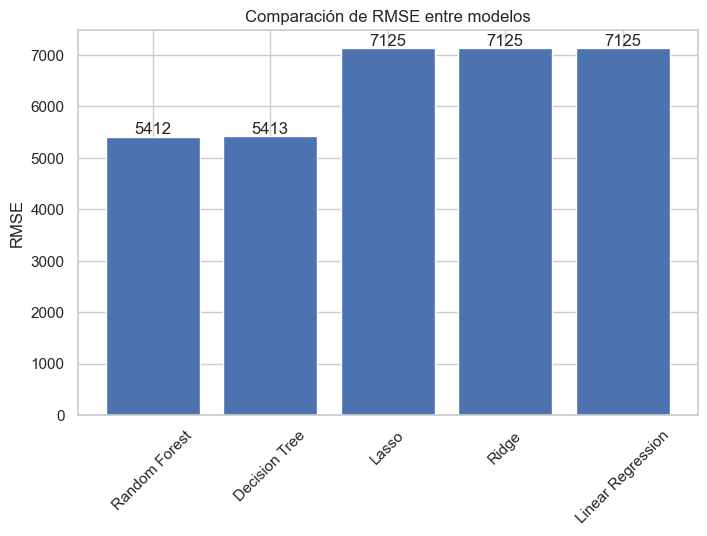

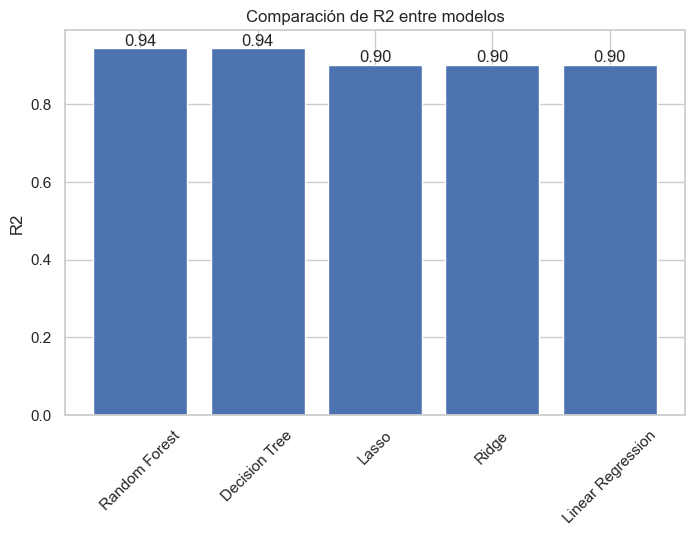

In [89]:
# RMSE
plt.figure(figsize=(8,5))                                   # Crear una nueva figura para el gráfico con tamaño de 8x5 pulgadas
plt.bar(df_resultados["Modelo"], df_resultados["RMSE"])     # Crear un gráfico de barras para comparar el RMSE de cada modelo utilizando los datos del DataFrame de resultados    

# agregar valores encima de las barras
for i, v in enumerate(df_resultados["RMSE"]):               # Iterar sobre los valores de RMSE para agregar etiquetas con los valores numéricos encima de cada barra en el gráfico
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')    # Agregar texto con el valor de RMSE formateado sin decimales, centrado horizontalmente y ubicado justo encima de la barra correspondiente

plt.xticks(rotation=45)                                     # Rotar las etiquetas del eje x 45 grados para mejorar la legibilidad de los nombres de los modelos
plt.title("Comparación de RMSE entre modelos")              # Establecer el título del gráfico para indicar que se está comparando el RMSE entre los modelos
plt.ylabel("RMSE")                                          # Establecer la etiqueta del eje y para indicar que se está midiendo el RMSE        
plt.show()                                                  # Mostrar el gráfico en pantalla

# R2
plt.figure(figsize=(8,5))                                   # Crear una nueva figura para el gráfico con tamaño de 8x5 pulgadas
plt.bar(df_resultados["Modelo"], df_resultados["R2"])       # Crear un gráfico de barras para comparar el R2 de cada modelo utilizando los datos del DataFrame de resultados

for i, v in enumerate(df_resultados["R2"]):                 # Iterar sobre los valores de R2 para agregar etiquetas con los valores numéricos encima de cada barra en el gráfico
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')    # Agregar texto con el valor de R2 formateado con dos decimales, centrado horizontalmente y ubicado justo encima de la barra correspondiente

plt.xticks(rotation=45)                                     # Rotar las etiquetas del eje x 45 grados para mejorar la legibilidad de los nombres de los modelos
plt.title("Comparación de R2 entre modelos")                # Establecer el título del gráfico para indicar que se está comparando el R2 entre los modelos
plt.ylabel("R2")                                            # Establecer la etiqueta del eje y para indicar que se está midiendo el R2
plt.show()                                                  # Mostrar el gráfico en pantalla

Se priorizaron las métricas RMSE y R² para la comparación gráfica, ya que permiten evaluar de manera clara el error del modelo y su capacidad explicativa.

El modelo Random Forest presenta el mejor desempeño, obteniendo el menor error (RMSE ≈ 5412) y el mayor R² (~0.94), lo que indica una alta capacidad predictiva.

El Árbol de Decisión muestra resultados muy similares, aunque ligeramente inferiores, lo que sugiere que un modelo más simple también logra capturar gran parte de la estructura de los datos.

Por otro lado, los modelos lineales (Regresión Lineal, Ridge y Lasso) presentan un rendimiento menor (RMSE ≈ 7125 y R² ~0.90), lo que sugiere que la relación entre las variables y el precio no es completamente lineal.

En comparación con el baseline (Regresión Lineal), Random Forest mejora significativamente la predicción, por lo que se selecciona como el modelo final.

### 10. Genera una conclusión final respecto a qué tan útiles son los resultados encontrados para resolver el problema propuesto y define cuáles podrían ser los próximos pasos para el proyecto.

### Conclusión final

Los resultados obtenidos permiten concluir que es factible predecir el precio de los vuelos con un buen nivel de precisión, alcanzando un R² cercano a 0.94 con el modelo Random Forest. Esto indica que el modelo logra capturar adecuadamente la variabilidad del precio en función de las variables disponibles.

La mejora significativa respecto al baseline (Regresión Lineal) demuestra que el problema presenta relaciones no lineales, las cuales son mejor modeladas por algoritmos basados en árboles.

En este contexto, variables como la clase del vuelo, la duración, la aerolínea y la cantidad de escalas resultan determinantes en la predicción.

Desde una perspectiva de negocio, estos resultados son útiles, ya que permiten:
- Estimar precios de vuelos de manera automatizada.
- Apoyar decisiones de compra o recomendación para usuarios.
- Detectar patrones de precios según características del vuelo.

### Próximos pasos

Para mejorar y escalar la solución, se proponen las siguientes líneas de trabajo:
- Incorporar nuevas variables: como anticipación de compra (days_left), demanda, temporada, eventos especiales o comportamiento histórico de precios.
- Optimización avanzada del modelo: aumentar el espacio de búsqueda de hiperparámetros y el número de iteraciones en RandomizedSearch para mejorar el desempeño del modelo.
- Tratamiento de outliers: evaluar su impacto y aplicar técnicas de reducción si es necesario.
- Validación más robusta: utilizar validación cruzada más profunda o datasets adicionales.
- Despliegue del modelo: implementar una API o sistema que permita realizar predicciones en tiempo real.
- Monitoreo del modelo: evaluar el desempeño en producción y detectar posibles desviaciones (drift).

En conclusión, el modelo desarrollado no solo resuelve el problema planteado, sino que también sienta las bases para una solución escalable y aplicable en entornos reales de negocio.